Packages loaded successfully.

Validation designs:
P01-P08 -> P09
P01-P09 -> P10

Required input files found.

Number of treatment sites: 10

Controls per treatment:
matched_treatment_site_id
treatment_0001    5
treatment_0002    5
treatment_0003    5
treatment_0004    5
treatment_0005    5
treatment_0006    5
treatment_0007    5
treatment_0008    5
treatment_0009    5
treatment_0010    5
Name: site_id, dtype: int64

P01-P10 inventory rows: 1200

Extracting P01-P10 image features...
Processing image 1188/1188

Feature extraction complete.
Feature rows: 1188


##############################################################################################################
RUNNING VALIDATION: P01-P08 -> P09
##############################################################################################################

SENSOR: SENTINEL1

treatment_0001: 5 donors
Training RMSE = 0.4492
P09 RMSE = 0.4892

treatment_0002: 5 donors
Training RMSE = 0.3685
P09 RMSE = 0.6876

treatment_0003: 5 donor

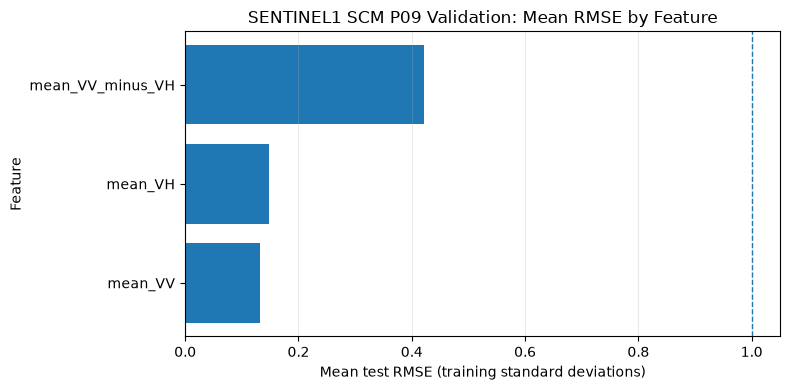

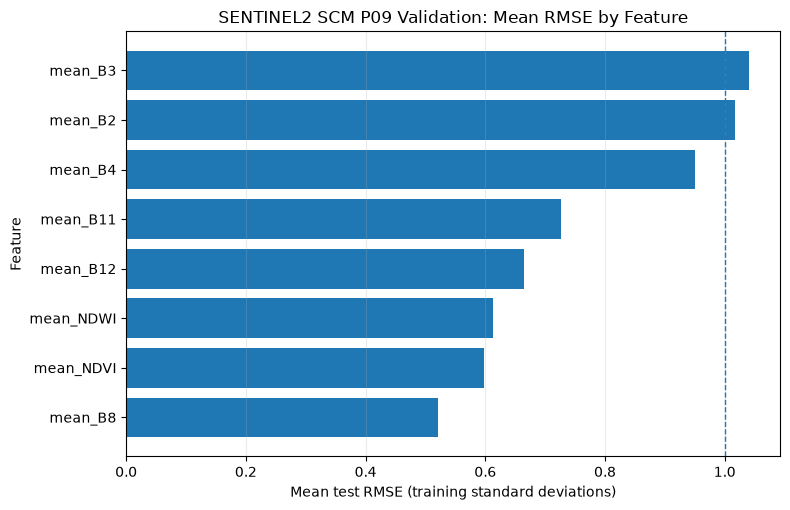

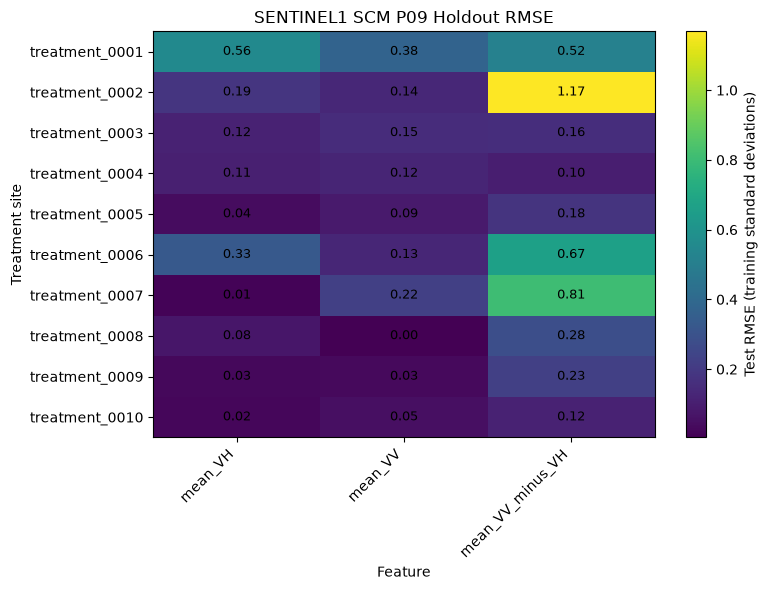

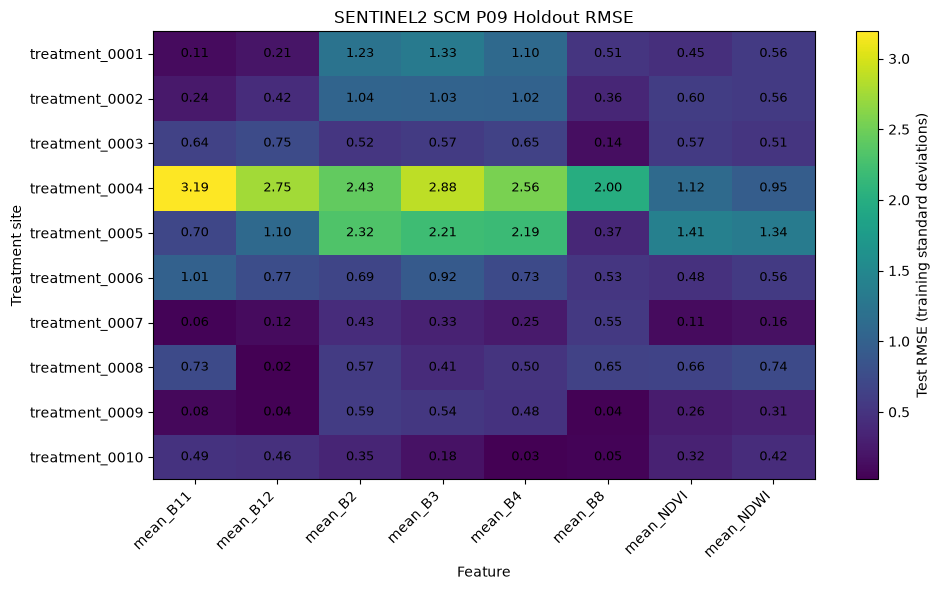

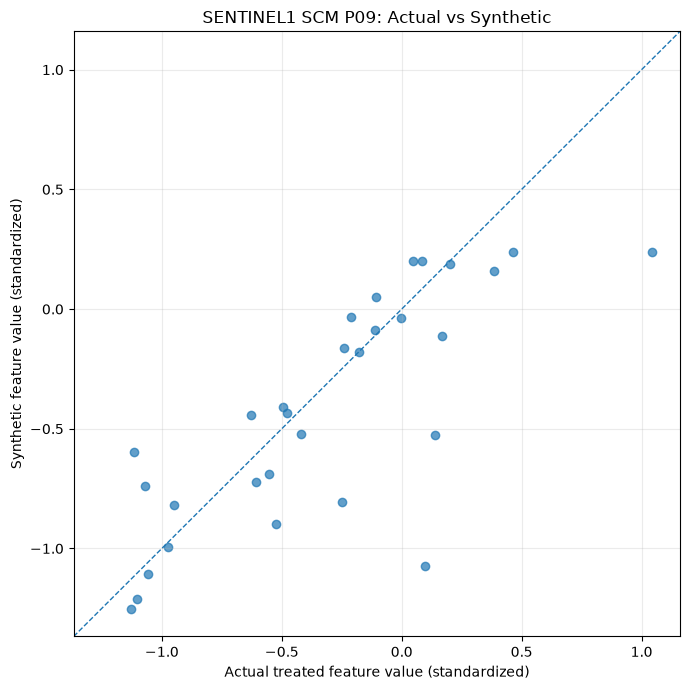

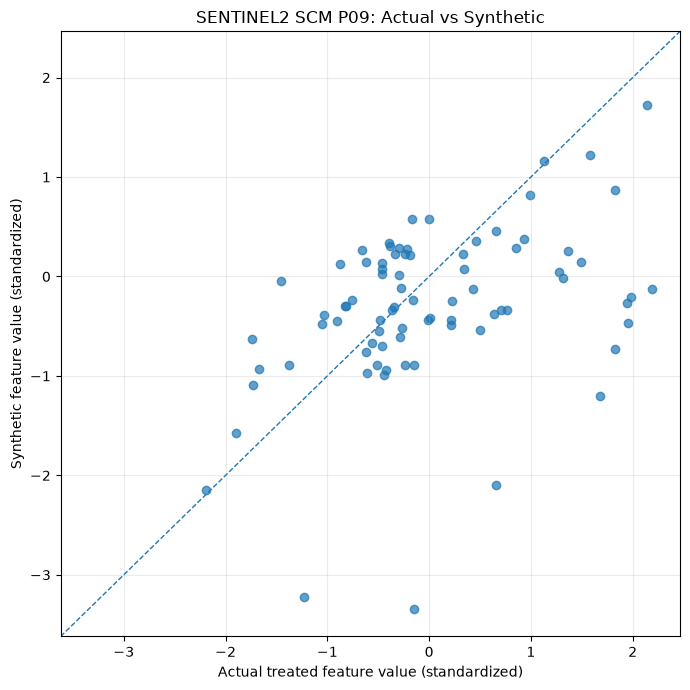

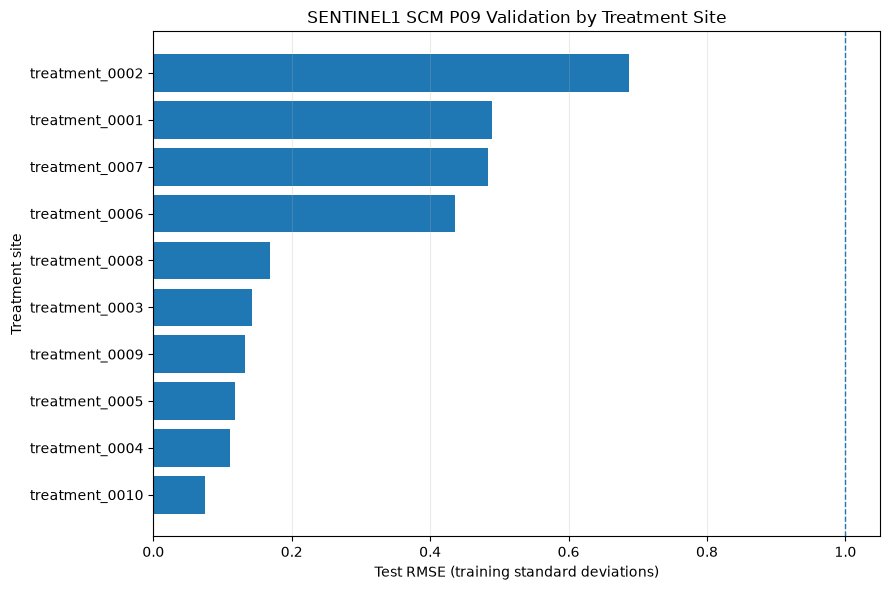

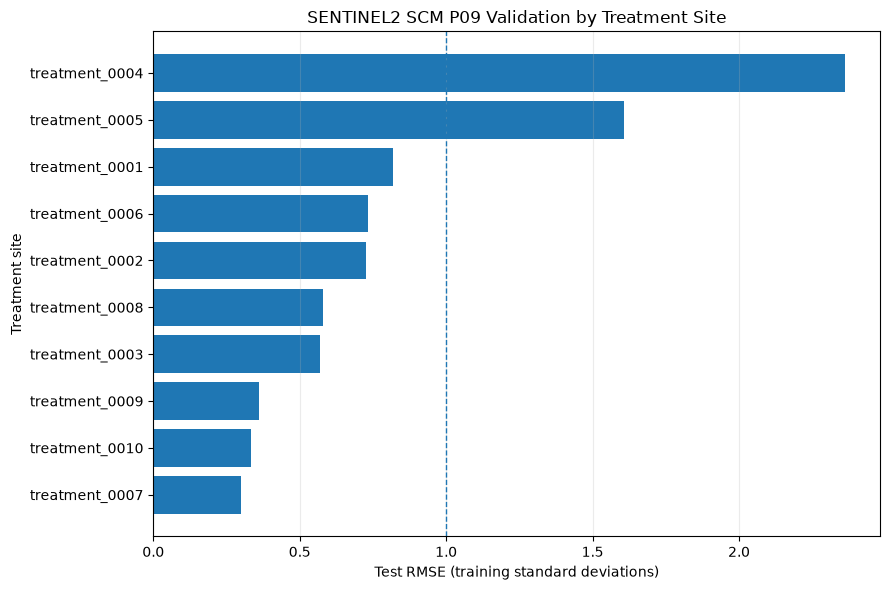


P01-P08 -> P09 RESULTS
   sensor treatment_site  training_rmse_standardized  test_rmse_standardized  test_to_training_rmse_ratio  largest_donor_weight  effective_number_of_donors validation_flag
sentinel1 treatment_0010                    0.360797                0.074270                     0.205850              0.853725                    1.332903            good
sentinel1 treatment_0004                    0.191217                0.111133                     0.581185              0.638542                    2.097489            good
sentinel1 treatment_0005                    0.252474                0.117719                     0.466260              0.494285                    2.899228            good
sentinel1 treatment_0009                    0.164547                0.133129                     0.809064              0.362636                    4.143719            good
sentinel1 treatment_0003                    0.155817                0.142574                     0.915008           

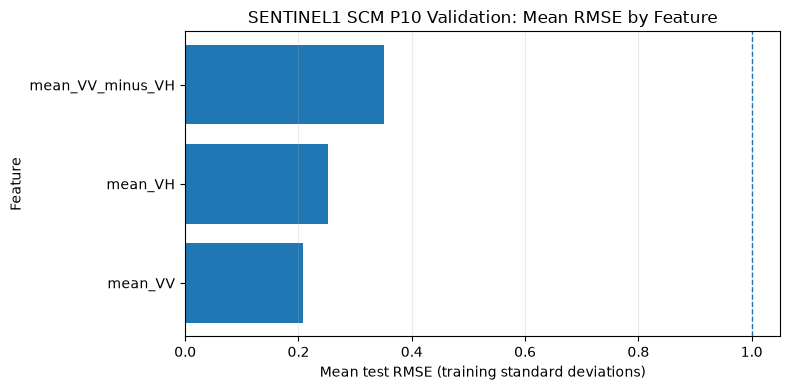

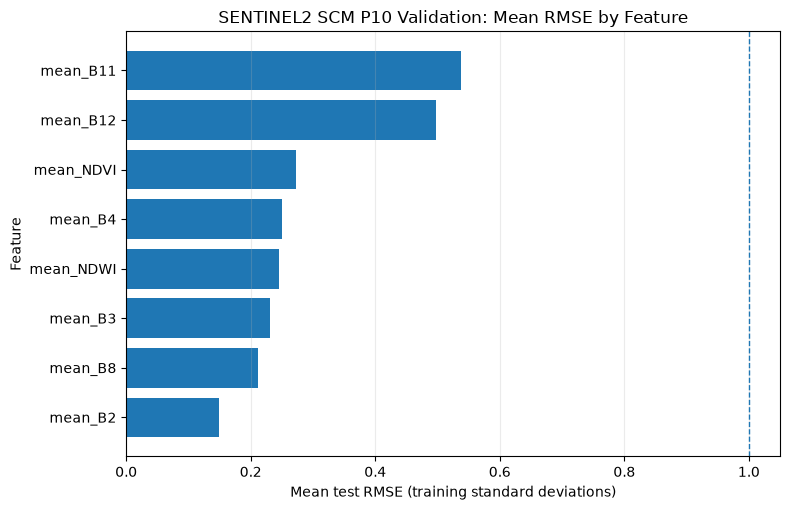

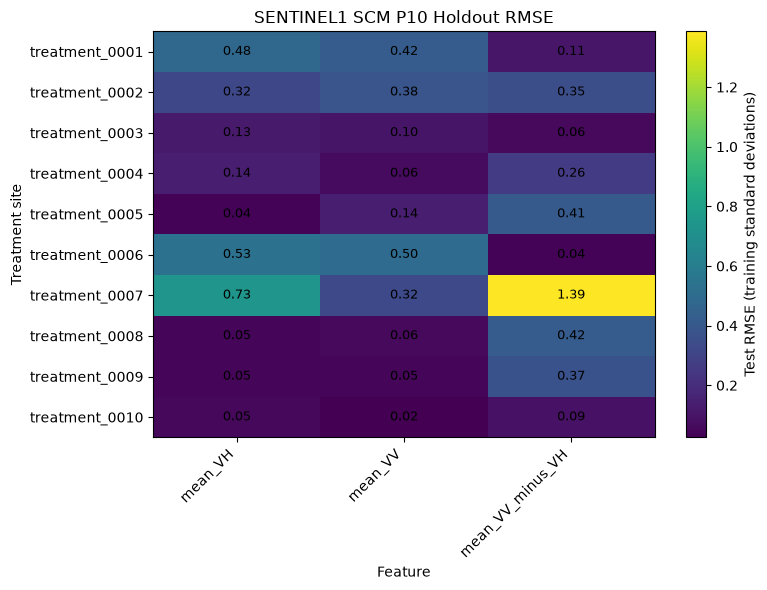

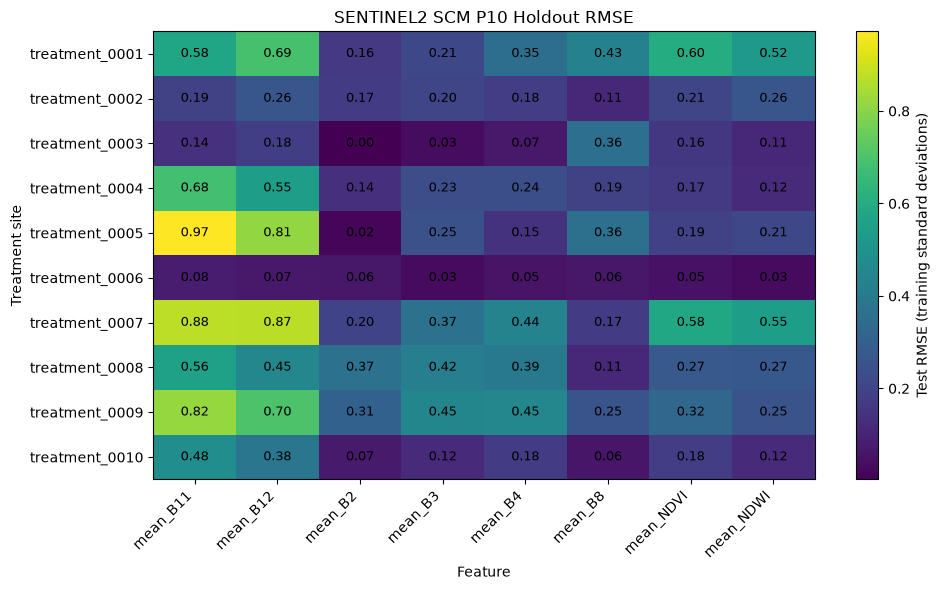

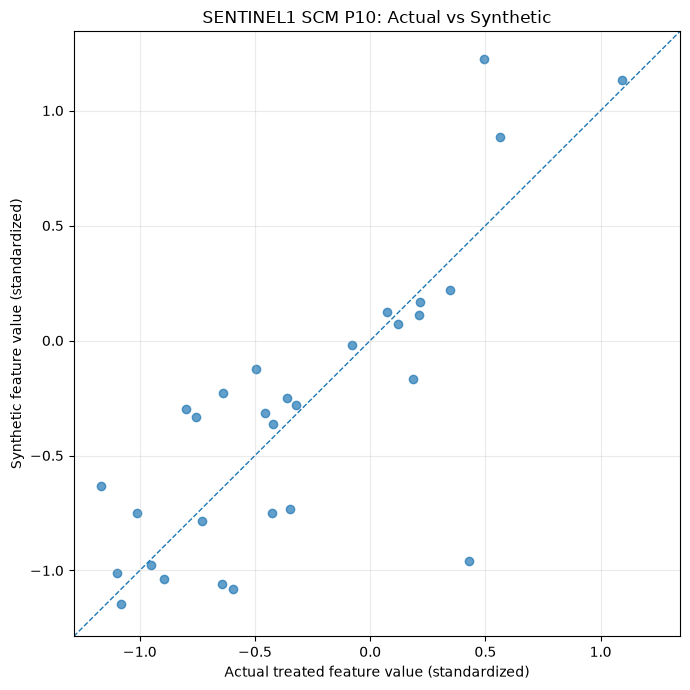

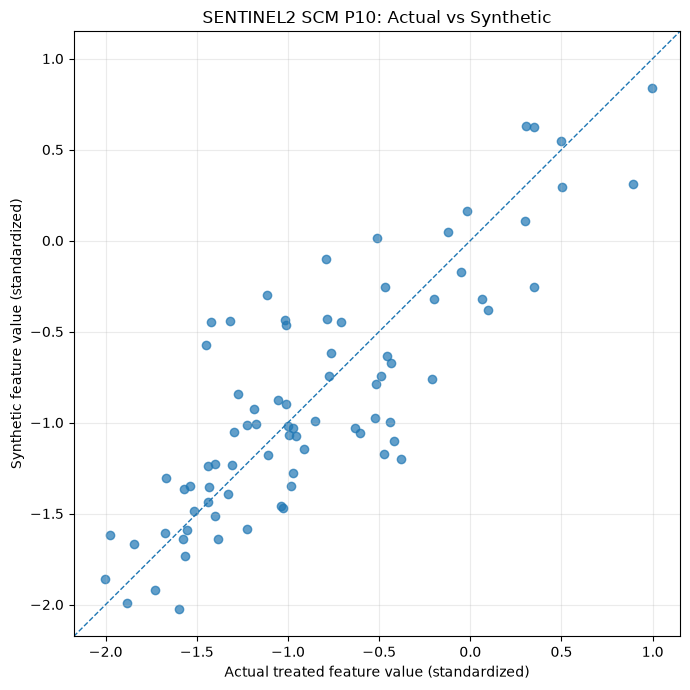

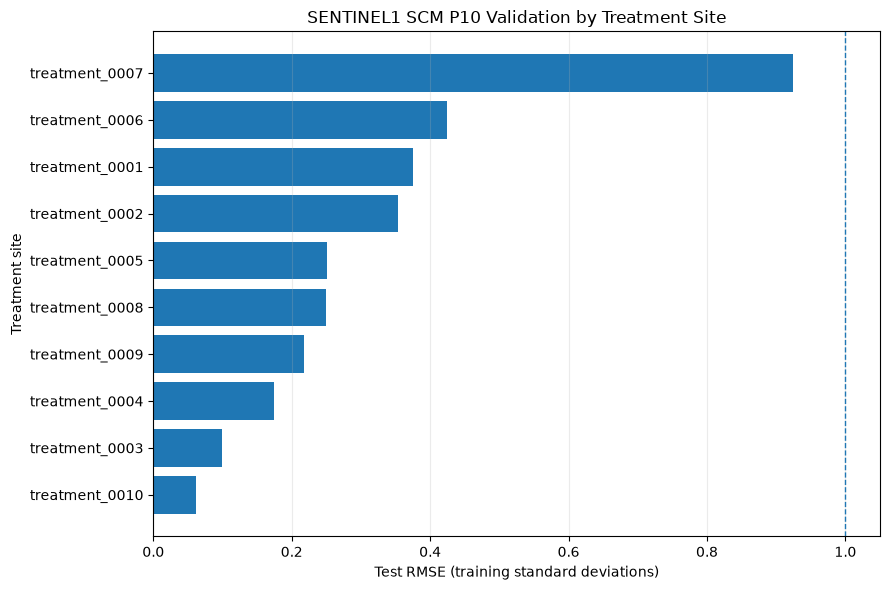

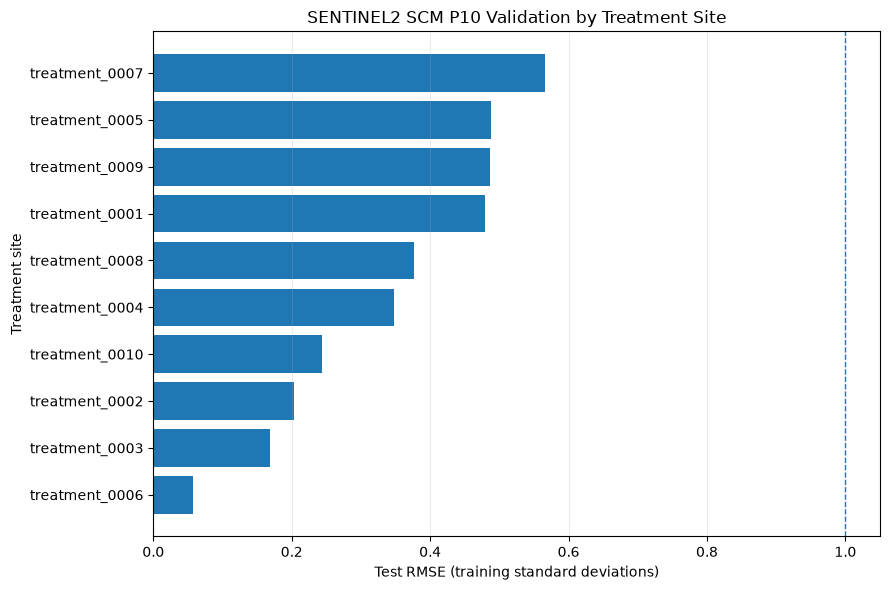


P01-P09 -> P10 RESULTS
   sensor treatment_site  training_rmse_standardized  test_rmse_standardized  test_to_training_rmse_ratio  largest_donor_weight  effective_number_of_donors validation_flag
sentinel1 treatment_0010                    0.350894                0.061575                     0.175480              0.846939                    1.350013            good
sentinel1 treatment_0003                    0.155973                0.098734                     0.633018              0.719847                    1.703211            good
sentinel1 treatment_0004                    0.187915                0.174900                     0.930737              0.648505                    2.085158            good
sentinel1 treatment_0009                    0.165961                0.217083                     1.308037              0.376301                    4.094088            good
sentinel1 treatment_0008                    0.263209                0.249011                     0.946056           

In [1]:
# =============================================================================
# 16_test_scm_single_period_validation.ipynb
#
# PURPOSE
# =============================================================================
#
# Expanding-window single-period holdout validation for feature-based SCM.
#
# This notebook automatically runs TWO validation exercises:
#
#   Validation 1:
#       P01-P08 = training
#       P09     = held-out test
#       output  = test/scm_validation/test_09/
#
#   Validation 2:
#       P01-P09 = training
#       P10     = held-out test
#       output  = test/scm_validation/test_10/
#
# P01-P10 image features are extracted ONCE.
#
# For EACH validation:
#
#   1. Estimate feature standardization from training periods only.
#   2. Standardize training and test observations using training scaler.
#   3. Estimate SCM donor weights from training periods only.
#   4. Freeze weights.
#   5. Predict held-out period.
#   6. Calculate feature- and site-level validation errors.
#   7. Save CSV, Excel, and figures.
#
# P11-P20 ARE NOT USED.
#
#
# SCM
# =============================================================================
#
# One weight vector is estimated for each:
#
#       treatment site × sensor
#
# using all standardized period × feature observations jointly.
#
#       min_w ||Y_T - X_C w||²
#
# subject to:
#
#       w_j >= 0
#       sum(w_j) = 1
#
#
# OUTPUT
# =============================================================================
#
# test/scm_validation/
#
# ├── test_09/
# │   ├── 01_extracted_features.csv
# │   ├── 02_scm_weights.csv
# │   ├── 03_training_fit.csv
# │   ├── 04_test_results.csv
# │   ├── 05_feature_test_rmse.csv
# │   ├── 06_site_summary.csv
# │   ├── 07_feature_summary.csv
# │   ├── 08_scm_test.xlsx
# │   └── figures/
# │
# └── test_10/
#     ├── same files
#     └── figures/
#
# =============================================================================


# =============================================================================
# 1. Packages
# =============================================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import rasterio

from scipy.optimize import minimize

import matplotlib.pyplot as plt


warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
)


print("Packages loaded successfully.")


# =============================================================================
# 2. Project paths
# =============================================================================

BASE_DIR = Path(
    "/Users/gaoyujuan/REAP Dropbox/Gao yujuan/"
    "Virginia Tech/CALS/datasets"
)

FINALS_DIR = BASE_DIR / "finals"

BIWEEKLY_DIR = (
    FINALS_DIR /
    "biweekly_datasets"
)

BIWEEKLY_QUALITY_FILE = (
    BIWEEKLY_DIR /
    "biweekly_image_quality.csv"
)

SELECTED_SAMPLE_FILE = (
    FINALS_DIR /
    "daily_datasets" /
    "selected_site_sample.csv"
)

TEST_DIR = (
    BASE_DIR /
    "test"
)

SCM_VALIDATION_DIR = (
    TEST_DIR /
    "scm_validation"
)

SCM_VALIDATION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# =============================================================================
# 3. Validation designs
#
# BOTH will run automatically.
# =============================================================================

VALIDATION_DESIGNS = [

    {
        "train_periods": list(range(1, 9)),
        "test_period": 9,
    },

    {
        "train_periods": list(range(1, 10)),
        "test_period": 10,
    },

]


print("\nValidation designs:")

for design in VALIDATION_DESIGNS:

    print(
        f"P01-P{design['train_periods'][-1]:02d}"
        f" -> P{design['test_period']:02d}"
    )


# =============================================================================
# 4. Sensor bands
# =============================================================================

SENSOR_BANDS = {

    "sentinel1": [
        "VV",
        "VH",
        "VV_minus_VH",
    ],

    "sentinel2": [
        "B2",
        "B3",
        "B4",
        "B8",
        "B11",
        "B12",
        "NDVI",
        "NDWI",
    ],

}


# =============================================================================
# 5. Sequential period helper
# =============================================================================

def sequential_period(period_id):

    period_id = str(period_id)

    if period_id.startswith("before_"):

        return int(
            period_id.split("P")[-1]
        )

    if period_id.startswith("after_"):

        return (
            10
            +
            int(
                period_id.split("P")[-1]
            )
        )

    return np.nan


# =============================================================================
# 6. Verify inputs
# =============================================================================

required_files = [
    BIWEEKLY_QUALITY_FILE,
    SELECTED_SAMPLE_FILE,
]

missing_files = [
    file_path
    for file_path in required_files
    if not file_path.exists()
]

if missing_files:

    raise FileNotFoundError(
        "Required files missing:\n\n"
        +
        "\n".join(
            str(x)
            for x in missing_files
        )
    )

print("\nRequired input files found.")


# =============================================================================
# 7. Load selected sample
# =============================================================================

sample = pd.read_csv(
    SELECTED_SAMPLE_FILE
)

required_sample_columns = [
    "site_id",
    "group",
    "matched_treatment_site_id",
    "control_rank",
]

missing_sample_columns = [
    column
    for column in required_sample_columns
    if column not in sample.columns
]

if missing_sample_columns:

    raise ValueError(
        "selected_site_sample.csv missing columns: "
        +
        str(missing_sample_columns)
    )


sample["site_id"] = (
    sample["site_id"]
    .astype(str)
)

sample["group"] = (
    sample["group"]
    .astype(str)
    .str.strip()
    .str.lower()
)

sample["matched_treatment_site_id"] = (
    sample["matched_treatment_site_id"]
    .astype(str)
)

sample["control_rank"] = pd.to_numeric(
    sample["control_rank"],
    errors="coerce",
)


treatments = (
    sample
    .loc[
        sample["group"] == "treatment",
        "site_id",
    ]
    .drop_duplicates()
    .astype(str)
    .tolist()
)


print(
    "\nNumber of treatment sites:",
    len(treatments),
)


# =============================================================================
# 8. Check donor structure
# =============================================================================

controls_per_treatment = (
    sample
    .loc[
        sample["group"] == "counterfactual"
    ]
    .groupby(
        "matched_treatment_site_id"
    )["site_id"]
    .nunique()
)


print("\nControls per treatment:")

print(
    controls_per_treatment
)


# =============================================================================
# 9. Load biweekly image inventory
# =============================================================================

quality = pd.read_csv(
    BIWEEKLY_QUALITY_FILE
)

required_quality_columns = [
    "site_id",
    "group",
    "sensor",
    "period_id",
    "output_file",
]

missing_quality_columns = [
    column
    for column in required_quality_columns
    if column not in quality.columns
]

if missing_quality_columns:

    raise ValueError(
        "biweekly_image_quality.csv missing columns: "
        +
        str(missing_quality_columns)
    )


quality["site_id"] = (
    quality["site_id"]
    .astype(str)
)

quality["group"] = (
    quality["group"]
    .astype(str)
    .str.strip()
    .str.lower()
)

quality["sensor"] = (
    quality["sensor"]
    .astype(str)
    .str.strip()
    .str.lower()
)

quality["sequential_period"] = (
    quality["period_id"]
    .apply(sequential_period)
)


# =============================================================================
# 10. Restrict inventory
#
# Only selected sites and P01-P10.
# =============================================================================

selected_site_ids = set(
    sample["site_id"].astype(str)
)


quality = (
    quality
    .loc[
        quality["site_id"].isin(
            selected_site_ids
        )
        &
        quality["sequential_period"].isin(
            range(1, 11)
        )
    ]
    .copy()
)


print(
    "\nP01-P10 inventory rows:",
    len(quality),
)


# =============================================================================
# 11. Extract image features
# =============================================================================

def extract_image_features(
    file_path,
    sensor,
):

    if pd.isna(file_path):
        return None

    file_path = Path(
        str(file_path)
    )

    if not file_path.exists():
        return None

    if sensor not in SENSOR_BANDS:

        raise ValueError(
            f"Unknown sensor: {sensor}"
        )

    band_names = SENSOR_BANDS[sensor]

    with rasterio.open(file_path) as src:

        data = (
            src.read(masked=True)
            .astype("float32")
            .filled(np.nan)
        )

    if data.shape[0] != len(band_names):

        raise ValueError(
            f"{file_path}: expected "
            f"{len(band_names)} bands, "
            f"found {data.shape[0]}"
        )

    output = {}

    for band_index, band_name in enumerate(
        band_names
    ):

        band = data[band_index]

        finite = np.isfinite(band)

        output[
            f"mean_{band_name}"
        ] = (
            float(np.mean(band[finite]))
            if finite.any()
            else np.nan
        )

    return output


# =============================================================================
# 12. Extract P01-P10 ONCE
# =============================================================================

print(
    "\nExtracting P01-P10 image features..."
)


feature_records = []


usable_quality = (
    quality
    .loc[
        quality["output_file"].notna()
    ]
    .copy()
)


for row_number, (_, row) in enumerate(
    usable_quality.iterrows(),
    start=1,
):

    if (
        row_number == 1
        or
        row_number % 100 == 0
        or
        row_number == len(usable_quality)
    ):

        print(
            f"\rProcessing image "
            f"{row_number}/{len(usable_quality)}",
            end="",
        )

    sensor = str(
        row["sensor"]
    )

    try:

        extracted = extract_image_features(
            row["output_file"],
            sensor,
        )

        if extracted is None:
            continue

        record = {

            "site_id":
                str(row["site_id"]),

            "group":
                str(row["group"]),

            "sensor":
                sensor,

            "period_id":
                str(row["period_id"]),

            "sequential_period":
                int(row["sequential_period"]),

            "period_start":
                row.get(
                    "period_start",
                    np.nan,
                ),

            "period_end":
                row.get(
                    "period_end",
                    np.nan,
                ),

            "valid_pixel_fraction":
                row.get(
                    "valid_pixel_fraction",
                    np.nan,
                ),

            "valid_pixel_percentage":
                row.get(
                    "valid_pixel_percentage",
                    np.nan,
                ),

            "output_file":
                str(row["output_file"]),

        }

        record.update(extracted)

        feature_records.append(record)

    except Exception as error:

        print(
            "\nFeature extraction failed:"
        )

        print(row["output_file"])

        print(error)


print()


features_master = pd.DataFrame(
    feature_records
)


if features_master.empty:

    raise RuntimeError(
        "No features extracted."
    )


# =============================================================================
# 13. Attach matching metadata
# =============================================================================

sample_metadata = (
    sample[
        [
            "site_id",
            "group",
            "matched_treatment_site_id",
            "control_rank",
        ]
    ]
    .drop_duplicates()
)


features_master = (
    features_master
    .merge(
        sample_metadata,
        on=[
            "site_id",
            "group",
        ],
        how="left",
    )
)


print(
    "\nFeature extraction complete."
)

print(
    "Feature rows:",
    len(features_master),
)


# =============================================================================
# 14. Training scaler
# =============================================================================

def get_training_scaler(
    dataframe,
    feature_columns,
    training_periods,
):

    training = (
        dataframe
        .loc[
            dataframe[
                "sequential_period"
            ].isin(
                training_periods
            )
        ]
        .copy()
    )

    means = (
        training[
            feature_columns
        ]
        .mean()
    )

    stds = (
        training[
            feature_columns
        ]
        .std()
    )

    stds = (
        stds
        .replace(0, 1)
        .fillna(1)
    )

    return means, stds


# =============================================================================
# 15. Create site matrix
# =============================================================================

def create_site_matrix(
    dataframe,
    site_id,
    sensor,
    periods,
    feature_columns,
):

    subset = (
        dataframe
        .loc[
            (
                dataframe["site_id"]
                ==
                str(site_id)
            )
            &
            (
                dataframe["sensor"]
                ==
                sensor
            )
            &
            (
                dataframe[
                    "sequential_period"
                ].isin(periods)
            )
        ]
        .copy()
    )

    subset = (
        subset
        .drop_duplicates(
            subset=[
                "sequential_period"
            ]
        )
        .set_index(
            "sequential_period"
        )
        .reindex(periods)
    )

    return (
        subset[
            feature_columns
        ]
        .to_numpy(
            dtype=float
        )
    )


# =============================================================================
# 16. SCM optimizer
# =============================================================================

def estimate_scm_weights(
    treated_matrix,
    donor_matrices,
):

    number_of_donors = len(
        donor_matrices
    )

    if number_of_donors == 0:

        raise ValueError(
            "No donors supplied."
        )

    y = (
        treated_matrix
        .reshape(-1)
    )

    X = np.column_stack(
        [
            donor_matrix.reshape(-1)
            for donor_matrix
            in donor_matrices
        ]
    )

    valid = (
        np.isfinite(y)
        &
        np.isfinite(X).all(axis=1)
    )

    y = y[valid]

    X = X[valid, :]

    if len(y) == 0:

        raise ValueError(
            "No complete training observations."
        )

    def objective(weights):

        residual = (
            y
            -
            X @ weights
        )

        return float(
            np.mean(
                residual ** 2
            )
        )

    initial_weights = np.repeat(
        1.0 / number_of_donors,
        number_of_donors,
    )

    bounds = [
        (0.0, 1.0)
        for _
        in range(number_of_donors)
    ]

    constraints = [

        {
            "type": "eq",
            "fun":
                lambda weights:
                np.sum(weights) - 1.0,
        }

    ]

    result = minimize(
        objective,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={
            "maxiter": 5000,
            "ftol": 1e-12,
        },
    )

    if not result.success:

        raise RuntimeError(
            "SCM optimization failed: "
            +
            result.message
        )

    return (
        result.x,
        float(result.fun),
        int(valid.sum()),
    )


# =============================================================================
# 17. Weighted prediction
# =============================================================================

def weighted_prediction(
    donor_matrices,
    weights,
):

    stack = np.stack(
        donor_matrices,
        axis=0,
    )

    return np.tensordot(
        weights,
        stack,
        axes=(0, 0),
    )


# =============================================================================
# 18. RUN BOTH VALIDATION DESIGNS
# =============================================================================

all_validation_summaries = []


for validation_design in VALIDATION_DESIGNS:

    # =========================================================================
    # Validation configuration
    # =========================================================================

    TRAIN_PERIODS = (
        validation_design[
            "train_periods"
        ]
    )

    TEST_PERIOD = (
        validation_design[
            "test_period"
        ]
    )

    TRAIN_LABEL = (
        f"P01-P{TRAIN_PERIODS[-1]:02d}"
    )

    TEST_LABEL = (
        f"P{TEST_PERIOD:02d}"
    )


    print(
        "\n\n"
        + "#" * 110
    )

    print(
        f"RUNNING VALIDATION: "
        f"{TRAIN_LABEL} -> {TEST_LABEL}"
    )

    print(
        "#" * 110
    )


    # =========================================================================
    # Output folder
    # =========================================================================

    OUTPUT_DIR = (
        SCM_VALIDATION_DIR /
        f"test_{TEST_PERIOD:02d}"
    )

    FIGURE_DIR = (
        OUTPUT_DIR /
        "figures"
    )

    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    FIGURE_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )


    # Generic filenames — no 09/10 in filenames

    FEATURE_FILE = (
        OUTPUT_DIR /
        "01_extracted_features.csv"
    )

    WEIGHT_FILE = (
        OUTPUT_DIR /
        "02_scm_weights.csv"
    )

    TRAINING_FILE = (
        OUTPUT_DIR /
        "03_training_fit.csv"
    )

    TEST_FILE = (
        OUTPUT_DIR /
        "04_test_results.csv"
    )

    FEATURE_RMSE_FILE = (
        OUTPUT_DIR /
        "05_feature_test_rmse.csv"
    )

    SUMMARY_FILE = (
        OUTPUT_DIR /
        "06_site_summary.csv"
    )

    FEATURE_SUMMARY_FILE = (
        OUTPUT_DIR /
        "07_feature_summary.csv"
    )

    EXCEL_FILE = (
        OUTPUT_DIR /
        "08_scm_test.xlsx"
    )


    # =========================================================================
    # Only save images relevant to current validation
    # =========================================================================

    features = (
        features_master
        .loc[
            features_master[
                "sequential_period"
            ].isin(
                TRAIN_PERIODS
                +
                [TEST_PERIOD]
            )
        ]
        .copy()
    )


    features.to_csv(
        FEATURE_FILE,
        index=False,
    )


    # =========================================================================
    # Containers
    # =========================================================================

    weight_records = []

    training_records = []

    test_records = []

    summary_records = []


    # =========================================================================
    # Sensor loop
    # =========================================================================

    for sensor in [
        "sentinel1",
        "sentinel2",
    ]:

        print(
            "\n"
            + "=" * 100
        )

        print(
            "SENSOR:",
            sensor.upper()
        )

        print(
            "=" * 100
        )


        feature_columns = [

            f"mean_{band}"

            for band
            in SENSOR_BANDS[sensor]

        ]


        sensor_data = (
            features
            .loc[
                features["sensor"]
                ==
                sensor
            ]
            .copy()
        )


        if sensor_data.empty:

            print(
                "No data available."
            )

            continue


        # =====================================================================
        # TRAINING-ONLY STANDARDIZATION
        # =====================================================================

        feature_means, feature_stds = (
            get_training_scaler(
                sensor_data,
                feature_columns,
                TRAIN_PERIODS,
            )
        )


        standardized = (
            sensor_data.copy()
        )


        standardized[
            feature_columns
        ] = (

            standardized[
                feature_columns
            ]

            -

            feature_means

        ) / feature_stds


        # =====================================================================
        # Treatment loop
        # =====================================================================

        for treatment_site in treatments:

            treatment_site = str(
                treatment_site
            )


            donors = (
                sample
                .loc[
                    (
                        sample["group"]
                        ==
                        "counterfactual"
                    )
                    &
                    (
                        sample[
                            "matched_treatment_site_id"
                        ]
                        ==
                        treatment_site
                    )
                ]
                .sort_values(
                    "control_rank"
                )
                ["site_id"]
                .astype(str)
                .tolist()
            )


            if len(donors) == 0:

                continue


            print(
                f"\n{treatment_site}: "
                f"{len(donors)} donors"
            )


            # =================================================================
            # TRAINING MATRICES
            # =================================================================

            treated_train = (
                create_site_matrix(
                    standardized,
                    treatment_site,
                    sensor,
                    TRAIN_PERIODS,
                    feature_columns,
                )
            )


            donor_train = [

                create_site_matrix(
                    standardized,
                    donor,
                    sensor,
                    TRAIN_PERIODS,
                    feature_columns,
                )

                for donor
                in donors

            ]


            # =================================================================
            # ESTIMATE SCM
            # =================================================================

            try:

                (
                    weights,
                    train_loss,
                    n_training_values,
                ) = estimate_scm_weights(
                    treated_train,
                    donor_train,
                )

            except Exception as error:

                print(
                    "SCM failed:",
                    error
                )

                continue


            # =================================================================
            # SAVE WEIGHTS
            # =================================================================

            for donor, weight in zip(
                donors,
                weights,
            ):

                weight_records.append(
                    {
                        "sensor":
                            sensor,

                        "treatment_site":
                            treatment_site,

                        "training_periods":
                            TRAIN_LABEL,

                        "test_period":
                            TEST_LABEL,

                        "donor_site":
                            donor,

                        "weight":
                            float(weight),
                    }
                )


            # =================================================================
            # TRAINING FIT
            # =================================================================

            predicted_train = (
                weighted_prediction(
                    donor_train,
                    weights,
                )
            )


            train_errors = (
                treated_train
                -
                predicted_train
            )


            finite_train = (
                train_errors[
                    np.isfinite(
                        train_errors
                    )
                ]
            )


            training_rmse = (
                float(
                    np.sqrt(
                        np.mean(
                            finite_train ** 2
                        )
                    )
                )
                if len(finite_train) > 0
                else np.nan
            )


            for period_index, period_number in enumerate(
                TRAIN_PERIODS
            ):

                for feature_index, feature_name in enumerate(
                    feature_columns
                ):

                    actual = (
                        treated_train[
                            period_index,
                            feature_index
                        ]
                    )

                    synthetic = (
                        predicted_train[
                            period_index,
                            feature_index
                        ]
                    )

                    error = (
                        actual - synthetic
                        if
                        np.isfinite(actual)
                        and
                        np.isfinite(synthetic)
                        else np.nan
                    )


                    training_records.append(
                        {
                            "sensor":
                                sensor,

                            "treatment_site":
                                treatment_site,

                            "training_periods":
                                TRAIN_LABEL,

                            "test_period":
                                TEST_LABEL,

                            "period":
                                period_number,

                            "period_id":
                                f"P{period_number:02d}",

                            "feature":
                                feature_name,

                            "actual_standardized":
                                actual,

                            "synthetic_standardized":
                                synthetic,

                            "error_standardized":
                                error,

                            "absolute_error_standardized":
                                abs(error)
                                if np.isfinite(error)
                                else np.nan,

                            "squared_error_standardized":
                                error ** 2
                                if np.isfinite(error)
                                else np.nan,
                        }
                    )


            # =================================================================
            # HELD-OUT TEST
            # =================================================================

            treated_test = (
                create_site_matrix(
                    standardized,
                    treatment_site,
                    sensor,
                    [TEST_PERIOD],
                    feature_columns,
                )
            )


            donor_test = [

                create_site_matrix(
                    standardized,
                    donor,
                    sensor,
                    [TEST_PERIOD],
                    feature_columns,
                )

                for donor
                in donors

            ]


            predicted_test = (
                weighted_prediction(
                    donor_test,
                    weights,
                )
            )


            test_errors = (
                treated_test
                -
                predicted_test
            )


            finite_test = (
                test_errors[
                    np.isfinite(
                        test_errors
                    )
                ]
            )


            test_rmse = (
                float(
                    np.sqrt(
                        np.mean(
                            finite_test ** 2
                        )
                    )
                )
                if len(finite_test) > 0
                else np.nan
            )


            print(
                f"Training RMSE = "
                f"{training_rmse:.4f}"
                if np.isfinite(training_rmse)
                else "Training RMSE = missing"
            )

            print(
                f"{TEST_LABEL} RMSE = "
                f"{test_rmse:.4f}"
                if np.isfinite(test_rmse)
                else f"{TEST_LABEL} RMSE = missing"
            )


            # =================================================================
            # FEATURE TEST RESULTS
            # =================================================================

            for feature_index, feature_name in enumerate(
                feature_columns
            ):

                actual_z = (
                    treated_test[
                        0,
                        feature_index
                    ]
                )

                synthetic_z = (
                    predicted_test[
                        0,
                        feature_index
                    ]
                )


                if (
                    np.isfinite(actual_z)
                    and
                    np.isfinite(synthetic_z)
                ):

                    error_z = (
                        actual_z
                        -
                        synthetic_z
                    )

                else:

                    error_z = np.nan


                mean_value = (
                    feature_means[
                        feature_name
                    ]
                )

                sd_value = (
                    feature_stds[
                        feature_name
                    ]
                )


                actual_original = (
                    actual_z * sd_value
                    +
                    mean_value
                    if np.isfinite(actual_z)
                    else np.nan
                )


                synthetic_original = (
                    synthetic_z * sd_value
                    +
                    mean_value
                    if np.isfinite(synthetic_z)
                    else np.nan
                )


                error_original = (
                    actual_original
                    -
                    synthetic_original
                    if
                    np.isfinite(actual_original)
                    and
                    np.isfinite(synthetic_original)
                    else np.nan
                )


                test_records.append(
                    {
                        "sensor":
                            sensor,

                        "treatment_site":
                            treatment_site,

                        "training_periods":
                            TRAIN_LABEL,

                        "test_period":
                            TEST_LABEL,

                        "feature":
                            feature_name,

                        "actual_standardized":
                            actual_z,

                        "synthetic_standardized":
                            synthetic_z,

                        "error_standardized":
                            error_z,

                        "absolute_error_standardized":
                            abs(error_z)
                            if np.isfinite(error_z)
                            else np.nan,

                        "squared_error_standardized":
                            error_z ** 2
                            if np.isfinite(error_z)
                            else np.nan,

                        "actual_original":
                            actual_original,

                        "synthetic_original":
                            synthetic_original,

                        "error_original":
                            error_original,
                    }
                )


            # =================================================================
            # SITE SUMMARY
            # =================================================================

            largest_weight = float(
                np.max(weights)
            )

            effective_donors = float(
                1.0
                /
                np.sum(weights ** 2)
            )


            rmse_ratio = (
                test_rmse
                /
                training_rmse
                if
                np.isfinite(test_rmse)
                and
                np.isfinite(training_rmse)
                and
                training_rmse > 0
                else np.nan
            )


            summary_records.append(
                {
                    "sensor":
                        sensor,

                    "treatment_site":
                        treatment_site,

                    "number_of_donors":
                        len(donors),

                    "training_periods":
                        TRAIN_LABEL,

                    "test_period":
                        TEST_LABEL,

                    "training_rmse_standardized":
                        training_rmse,

                    "test_rmse_standardized":
                        test_rmse,

                    "test_to_training_rmse_ratio":
                        rmse_ratio,

                    "largest_donor_weight":
                        largest_weight,

                    "effective_number_of_donors":
                        effective_donors,

                    "training_values_used":
                        n_training_values,
                }
            )


    # =========================================================================
    # 19. Convert results to DataFrames
    # =========================================================================

    scm_weights = pd.DataFrame(
        weight_records
    )

    training_fit = pd.DataFrame(
        training_records
    )

    test_results = pd.DataFrame(
        test_records
    )

    site_summary = pd.DataFrame(
        summary_records
    )


    if test_results.empty:

        print(
            f"\nNo valid results for {TEST_LABEL}."
        )

        continue


    # =========================================================================
    # 20. Feature-specific RMSE
    #
    # With one held-out period:
    #
    # RMSE = |actual - synthetic|
    #
    # =========================================================================

    feature_test_rmse = (
        test_results
        .groupby(
            [
                "sensor",
                "treatment_site",
                "feature",
            ],
            as_index=False,
        )
        .agg(

            feature_test_rmse_standardized=(
                "squared_error_standardized",
                lambda x:
                    float(
                        np.sqrt(
                            np.nanmean(x)
                        )
                    )
                    if x.notna().any()
                    else np.nan,
            ),

            feature_absolute_error_standardized=(
                "absolute_error_standardized",
                "mean",
            ),

            actual_standardized=(
                "actual_standardized",
                "mean",
            ),

            synthetic_standardized=(
                "synthetic_standardized",
                "mean",
            ),

            actual_original=(
                "actual_original",
                "mean",
            ),

            synthetic_original=(
                "synthetic_original",
                "mean",
            ),

            error_original=(
                "error_original",
                "mean",
            ),
        )
    )


    feature_test_rmse[
        "training_periods"
    ] = TRAIN_LABEL

    feature_test_rmse[
        "test_period"
    ] = TEST_LABEL


    # =========================================================================
    # 21. Validation diagnostic flags
    # =========================================================================

    if not site_summary.empty:

        site_summary[
            "validation_flag"
        ] = np.select(

            [
                site_summary[
                    "test_to_training_rmse_ratio"
                ] <= 1.5,

                site_summary[
                    "test_to_training_rmse_ratio"
                ] <= 2.0,
            ],

            [
                "good",
                "caution",
            ],

            default="poor",
        )


    # =========================================================================
    # 22. Feature summary across treatment sites
    # =========================================================================

    overall_feature_summary = (
        feature_test_rmse
        .groupby(
            [
                "sensor",
                "feature",
            ],
            as_index=False,
        )
        .agg(

            mean_test_rmse=(
                "feature_test_rmse_standardized",
                "mean",
            ),

            median_test_rmse=(
                "feature_test_rmse_standardized",
                "median",
            ),

            min_test_rmse=(
                "feature_test_rmse_standardized",
                "min",
            ),

            max_test_rmse=(
                "feature_test_rmse_standardized",
                "max",
            ),

            sd_test_rmse=(
                "feature_test_rmse_standardized",
                "std",
            ),

            number_of_treatment_sites=(
                "treatment_site",
                "nunique",
            ),
        )
    )


    overall_feature_summary[
        "training_periods"
    ] = TRAIN_LABEL

    overall_feature_summary[
        "test_period"
    ] = TEST_LABEL


    # =========================================================================
    # 23. Save CSV
    # =========================================================================

    scm_weights.to_csv(
        WEIGHT_FILE,
        index=False,
    )

    training_fit.to_csv(
        TRAINING_FILE,
        index=False,
    )

    test_results.to_csv(
        TEST_FILE,
        index=False,
    )

    feature_test_rmse.to_csv(
        FEATURE_RMSE_FILE,
        index=False,
    )

    site_summary.to_csv(
        SUMMARY_FILE,
        index=False,
    )

    overall_feature_summary.to_csv(
        FEATURE_SUMMARY_FILE,
        index=False,
    )


    # =========================================================================
    # 24. Excel
    #
    # Generic workbook/sheet names.
    # No 09 or 10 required in filenames.
    # =========================================================================

    with pd.ExcelWriter(
        EXCEL_FILE,
        engine="openpyxl",
    ) as writer:

        site_summary.to_excel(
            writer,
            sheet_name="site_summary",
            index=False,
        )

        overall_feature_summary.to_excel(
            writer,
            sheet_name="feature_summary",
            index=False,
        )

        feature_test_rmse.to_excel(
            writer,
            sheet_name="feature_test_rmse",
            index=False,
        )

        scm_weights.to_excel(
            writer,
            sheet_name="weights",
            index=False,
        )

        test_results.to_excel(
            writer,
            sheet_name="test_results",
            index=False,
        )

        training_fit.to_excel(
            writer,
            sheet_name="training_fit",
            index=False,
        )

        features.to_excel(
            writer,
            sheet_name="features",
            index=False,
        )


    # =========================================================================
    # 25. FIGURE 1 — Mean feature RMSE
    # =========================================================================

    for sensor in [
        "sentinel1",
        "sentinel2",
    ]:

        plot_data = (
            overall_feature_summary
            .loc[
                overall_feature_summary[
                    "sensor"
                ]
                ==
                sensor
            ]
            .sort_values(
                "mean_test_rmse"
            )
        )

        if plot_data.empty:
            continue


        fig, ax = plt.subplots(
            figsize=(
                8,
                max(
                    4,
                    len(plot_data) * 0.65,
                ),
            )
        )


        ax.barh(
            plot_data["feature"],
            plot_data["mean_test_rmse"],
        )

        ax.axvline(
            1.0,
            linestyle="--",
            linewidth=1,
        )

        ax.set_xlabel(
            "Mean test RMSE "
            "(training standard deviations)"
        )

        ax.set_ylabel(
            "Feature"
        )

        ax.set_title(
            f"{sensor.upper()} SCM "
            f"{TEST_LABEL} Validation: "
            "Mean RMSE by Feature"
        )

        ax.grid(
            axis="x",
            alpha=0.25,
        )

        plt.tight_layout()

        plt.savefig(
            FIGURE_DIR /
            f"01_{sensor}_mean_feature_rmse.png",
            dpi=300,
            bbox_inches="tight",
        )

        plt.show()

        plt.close()


    # =========================================================================
    # 26. FIGURE 2 — Treatment × feature heatmap
    # =========================================================================

    for sensor in [
        "sentinel1",
        "sentinel2",
    ]:

        subset = (
            feature_test_rmse
            .loc[
                feature_test_rmse[
                    "sensor"
                ]
                ==
                sensor
            ]
        )

        if subset.empty:
            continue


        heatmap = (
            subset
            .pivot(
                index="treatment_site",
                columns="feature",
                values=
                    "feature_test_rmse_standardized",
            )
            .sort_index()
        )


        fig, ax = plt.subplots(
            figsize=(
                max(
                    8,
                    heatmap.shape[1] * 1.25,
                ),
                max(
                    5,
                    heatmap.shape[0] * 0.60,
                ),
            )
        )


        image = ax.imshow(
            heatmap.values,
            aspect="auto",
        )


        ax.set_xticks(
            np.arange(
                heatmap.shape[1]
            )
        )

        ax.set_xticklabels(
            heatmap.columns,
            rotation=45,
            ha="right",
        )

        ax.set_yticks(
            np.arange(
                heatmap.shape[0]
            )
        )

        ax.set_yticklabels(
            heatmap.index
        )

        ax.set_xlabel(
            "Feature"
        )

        ax.set_ylabel(
            "Treatment site"
        )

        ax.set_title(
            f"{sensor.upper()} SCM "
            f"{TEST_LABEL} Holdout RMSE"
        )


        for i in range(
            heatmap.shape[0]
        ):

            for j in range(
                heatmap.shape[1]
            ):

                value = heatmap.iloc[
                    i,
                    j
                ]

                if pd.notna(value):

                    ax.text(
                        j,
                        i,
                        f"{value:.2f}",
                        ha="center",
                        va="center",
                        fontsize=9,
                    )


        colorbar = fig.colorbar(
            image,
            ax=ax,
        )

        colorbar.set_label(
            "Test RMSE "
            "(training standard deviations)"
        )

        plt.tight_layout()

        plt.savefig(
            FIGURE_DIR /
            f"02_{sensor}_treatment_feature_rmse.png",
            dpi=300,
            bbox_inches="tight",
        )

        plt.show()

        plt.close()


    # =========================================================================
    # 27. FIGURE 3 — Actual vs synthetic
    # =========================================================================

    for sensor in [
        "sentinel1",
        "sentinel2",
    ]:

        plot_data = (
            test_results
            .loc[
                test_results["sensor"]
                ==
                sensor
            ]
            .dropna(
                subset=[
                    "actual_standardized",
                    "synthetic_standardized",
                ]
            )
        )

        if plot_data.empty:
            continue


        values = np.concatenate(
            [
                plot_data[
                    "actual_standardized"
                ].to_numpy(),

                plot_data[
                    "synthetic_standardized"
                ].to_numpy(),
            ]
        )


        lower = float(
            np.nanmin(values)
        )

        upper = float(
            np.nanmax(values)
        )


        padding = (
            0.05
            *
            (upper - lower)
        )

        if padding == 0:
            padding = 0.1

        lower -= padding
        upper += padding


        fig, ax = plt.subplots(
            figsize=(7, 7)
        )


        ax.scatter(
            plot_data[
                "actual_standardized"
            ],
            plot_data[
                "synthetic_standardized"
            ],
            alpha=0.7,
        )


        ax.plot(
            [lower, upper],
            [lower, upper],
            linestyle="--",
            linewidth=1,
        )


        ax.set_xlim(
            lower,
            upper,
        )

        ax.set_ylim(
            lower,
            upper,
        )

        ax.set_xlabel(
            "Actual treated feature value "
            "(standardized)"
        )

        ax.set_ylabel(
            "Synthetic feature value "
            "(standardized)"
        )

        ax.set_title(
            f"{sensor.upper()} SCM "
            f"{TEST_LABEL}: "
            "Actual vs Synthetic"
        )

        ax.grid(
            alpha=0.25
        )

        plt.tight_layout()

        plt.savefig(
            FIGURE_DIR /
            f"03_{sensor}_actual_vs_synthetic.png",
            dpi=300,
            bbox_inches="tight",
        )

        plt.show()

        plt.close()


    # =========================================================================
    # 28. FIGURE 4 — Site-level RMSE
    # =========================================================================

    for sensor in [
        "sentinel1",
        "sentinel2",
    ]:

        plot_data = (
            site_summary
            .loc[
                site_summary["sensor"]
                ==
                sensor
            ]
            .sort_values(
                "test_rmse_standardized"
            )
        )

        if plot_data.empty:
            continue


        fig, ax = plt.subplots(
            figsize=(9, 6)
        )


        ax.barh(
            plot_data[
                "treatment_site"
            ],
            plot_data[
                "test_rmse_standardized"
            ],
        )


        ax.axvline(
            1.0,
            linestyle="--",
            linewidth=1,
        )


        ax.set_xlabel(
            "Test RMSE "
            "(training standard deviations)"
        )

        ax.set_ylabel(
            "Treatment site"
        )

        ax.set_title(
            f"{sensor.upper()} SCM "
            f"{TEST_LABEL} Validation "
            "by Treatment Site"
        )

        ax.grid(
            axis="x",
            alpha=0.25,
        )

        plt.tight_layout()

        plt.savefig(
            FIGURE_DIR /
            f"04_{sensor}_site_test_rmse.png",
            dpi=300,
            bbox_inches="tight",
        )

        plt.show()

        plt.close()


    # =========================================================================
    # 29. Print validation results
    # =========================================================================

    print(
        "\n"
        + "=" * 110
    )

    print(
        f"{TRAIN_LABEL} -> "
        f"{TEST_LABEL} RESULTS"
    )

    print(
        "=" * 110
    )


    if not site_summary.empty:

        print(
            site_summary[
                [
                    "sensor",
                    "treatment_site",
                    "training_rmse_standardized",
                    "test_rmse_standardized",
                    "test_to_training_rmse_ratio",
                    "largest_donor_weight",
                    "effective_number_of_donors",
                    "validation_flag",
                ]
            ]
            .sort_values(
                [
                    "sensor",
                    "test_rmse_standardized",
                ]
            )
            .to_string(
                index=False
            )
        )


    # =========================================================================
    # Save for combined comparison
    # =========================================================================

    temp_summary = (
        site_summary.copy()
    )

    temp_summary[
        "validation_design"
    ] = (
        f"{TRAIN_LABEL} -> {TEST_LABEL}"
    )

    all_validation_summaries.append(
        temp_summary
    )


    print(
        "\nSaved to:"
    )

    print(
        OUTPUT_DIR
    )


# =============================================================================
# 30. COMBINED P09 vs P10 VALIDATION COMPARISON
# =============================================================================

if all_validation_summaries:

    combined_validation = pd.concat(
        all_validation_summaries,
        ignore_index=True,
    )


    combined_file = (
        SCM_VALIDATION_DIR /
        "validation_comparison.csv"
    )


    combined_validation.to_csv(
        combined_file,
        index=False,
    )


    print(
        "\n"
        + "=" * 110
    )

    print(
        "P09 AND P10 VALIDATION COMPARISON"
    )

    print(
        "=" * 110
    )


    comparison = (
        combined_validation
        .groupby(
            [
                "validation_design",
                "sensor",
            ],
            as_index=False,
        )
        .agg(

            mean_training_rmse=(
                "training_rmse_standardized",
                "mean",
            ),

            mean_test_rmse=(
                "test_rmse_standardized",
                "mean",
            ),

            median_test_rmse=(
                "test_rmse_standardized",
                "median",
            ),

            number_of_sites=(
                "treatment_site",
                "nunique",
            ),

        )
    )


    print(
        comparison.to_string(
            index=False
        )
    )


# =============================================================================
# 31. FINAL
# =============================================================================

print(
    "\n"
    + "=" * 110
)

print(
    "NOTEBOOK 16 COMPLETE"
)

print(
    "=" * 110
)

print(
    "\nValidation 1:"
)

print(
    "P01-P08 -> P09"
)

print(
    SCM_VALIDATION_DIR /
    "test_09"
)

print(
    "\nValidation 2:"
)

print(
    "P01-P09 -> P10"
)

print(
    SCM_VALIDATION_DIR /
    "test_10"
)

print(
    "\nP11-P20 were not used."
)

print(
    "\nBoth validation exercises completed."
)